In [1]:
import copernicusmarine

In [2]:
%%time
ds = copernicusmarine.open_dataset(dataset_id='cmems_mod_med_phy-cur_my_4.2km_P1D-m')

INFO - 2026-04-23T15:40:08Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  lfortunato


Copernicus Marine password:

  ········


INFO - 2026-04-23T15:40:17Z - Selected dataset version: "202511"
INFO - 2026-04-23T15:40:17Z - Selected dataset part: "default"


CPU times: user 3.67 s, sys: 900 ms, total: 4.57 s
Wall time: 14.8 s


In [3]:
ds

<xarray.Dataset> Size: 6TB
Dimensions:    (depth: 141, latitude: 380, longitude: 1016, time: 14335)
Coordinates:
  * depth      (depth) float32 564B 1.018 3.166 5.465 ... 5.646e+03 5.754e+03
  * latitude   (latitude) float32 2kB 30.19 30.23 30.27 ... 45.9 45.94 45.98
  * longitude  (longitude) float32 4kB -6.0 -5.958 -5.917 ... 36.21 36.25 36.29
  * time       (time) datetime64[ns] 115kB 1987-01-01 1987-01-02 ... 2026-03-31
Data variables:
    uo         (time, depth, latitude, longitude) float32 3TB dask.array<chunksize=(100, 2, 380, 1016), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float32 3TB dask.array<chunksize=(100, 2, 380, 1016), meta=np.ndarray>
Attributes:
    Conventions:               CF-1.0
    bulletin_date:             20230707
    bulletin_type:             interim
    comment:                   Please check in CMEMS catalogue the INFO secti...
    contact:                   servicedesk.cmems@mercator-ocean.eu
    field_type:                daily_mean_centered_at_time_field
    institution:               Centro Euro-Mediterraneo sui Cambiamenti Clima...
    references:                Escudier, R., Clementi, E., Omar, M., Cipollon...
    source:                    MFS E3R1I
    title:                     Horizontal Velocity (3D) - Daily Mean
    copernicusmarine_version:  2.3.0

In [4]:
import hvplot.xarray
import panel as pn
pn.extension()

In [5]:
%%time
da = ds['uo'].sel(depth=0, time='2026-03-31 00:00', method='nearest').load()
da = ds['vo'].sel(depth=0, time='2026-03-31 00:00', method='nearest').load()


CPU times: user 2.09 s, sys: 1.1 s, total: 3.2 s
Wall time: 2.92 s


In [6]:
da.nbytes/1e6

1.54432

In [7]:
da.hvplot(x='longitude', y='latitude', rasterize=True, geo=True, cmap='turbo', tiles='OSM')

:DynamicMap   []
   :Overlay
      .WMTS.I  :WMTS   [Longitude,Latitude]
      .Image.I :Image   [longitude,latitude]   (northward ocean current velocity)

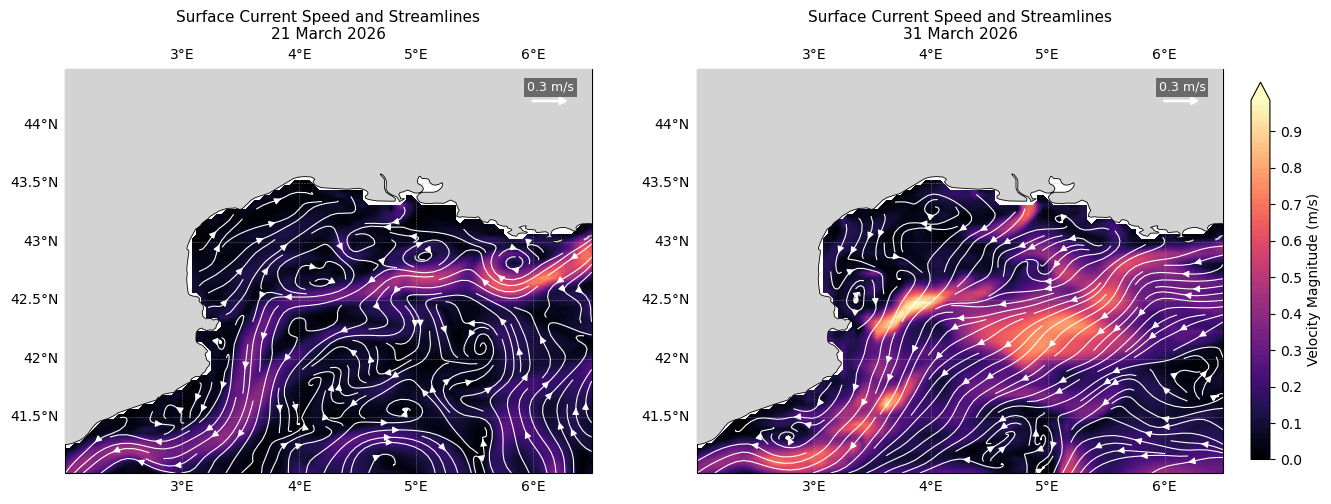

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

LON = slice(2.0, 6.5)
LAT = slice(41.0, 44.5)
DATES = ['2026-03-21 00:00', '2026-03-31 00:00']
TITLES = ['21 March 2026', '31 March 2026']

# --- Carica dati per entrambe le date ---
datasets = []
for date in DATES:
    u = ds['uo'].sel(depth=0, time=date, method='nearest').sel(longitude=LON, latitude=LAT).load()
    v = ds['vo'].sel(depth=0, time=date, method='nearest').sel(longitude=LON, latitude=LAT).load()
    spd = np.sqrt(u**2 + v**2)
    datasets.append({'u': u, 'v': v, 'spd': spd})

# --- Limiti colorbar comuni basati sul min/max del dataset ---
vmin = float(min(d['spd'].min() for d in datasets))
vmax = float(max(d['spd'].max() for d in datasets))
levels = np.linspace(vmin, vmax, 70)

lon = datasets[0]['u'].longitude.values
lat = datasets[0]['u'].latitude.values

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7),
    subplot_kw={'projection': ccrs.PlateCarree()},
)

for ax, data, title in zip(axes, datasets, TITLES):
    cf = ax.contourf(
        lon, lat, data['spd'].values,
        levels=levels,
        cmap='magma',
        transform=ccrs.PlateCarree(),
        extend='max',
    )

    ax.streamplot(
        lon, lat, data['u'].values, data['v'].values,
        transform=ccrs.PlateCarree(),
        density=2,
        linewidth=0.8,
        color='white',
        arrowsize=1.0,
    )

    # --- Vettore di riferimento 0.3 m/s in alto a destra ---
    ref_speed = 0.30
    lon_extent = lon.max() - lon.min()
    arrow_len = (ref_speed / vmax) * lon_extent * 0.25
    ref_lon = lon.max() - arrow_len * 1.5
    ref_lat = lat.max() - (lat.max() - lat.min()) * 0.08

    ax.annotate('',
                xy=(ref_lon + arrow_len, ref_lat),
                xytext=(ref_lon, ref_lat),
                xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle='->', color='white', lw=2),
                zorder=5)
    ax.text(ref_lon + arrow_len / 2, ref_lat + (lat.max() - lat.min()) * 0.025,
            '0.3 m/s', color='white', ha='center', fontsize=9,
            transform=ccrs.PlateCarree(),
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=2),
            zorder=5)

    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=4)

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', alpha=0.6)
    gl.right_labels = False

    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    ax.set_title(f'Surface Current Speed and Streamlines\n{title}', fontsize=11)

# --- Colorbar condivisa ---
cbar = fig.colorbar(cf, ax=axes, label='Velocity Magnitude (m/s)', shrink=0.7, pad=0.02)
cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.show()


CPU times: user 23.2 s, sys: 10.4 s, total: 33.6 s
Wall time: 25 s


Column
    [0] DiscreteSlider(name='Date', options=['2026-03-21', ...], value='2026-03-21')
    [1] Matplotlib(Figure, tight=True)
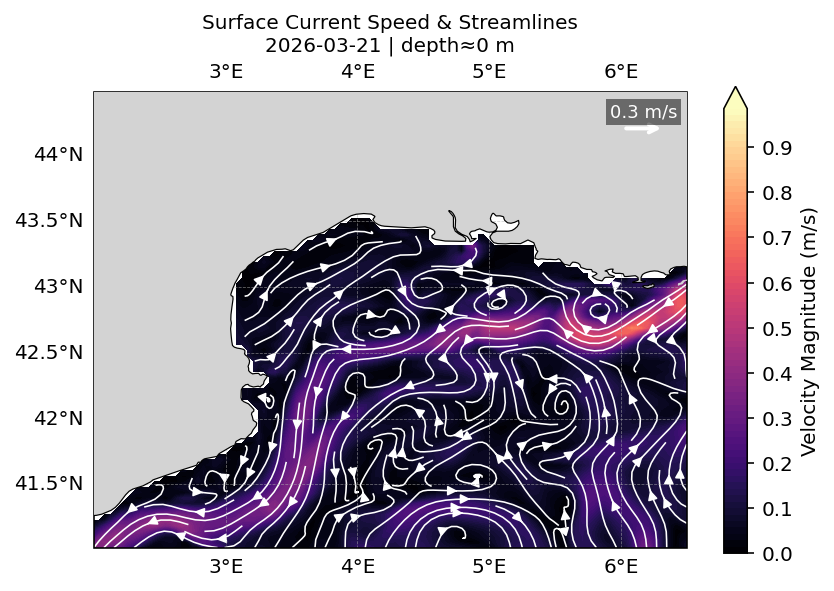

In [9]:
%%time
import panel as pn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd

pn.extension()

LON = slice(2.0, 6.5)
LAT = slice(41.0, 44.5)
dates = pd.date_range('2026-03-21', '2026-03-31', freq='D')

# --- Pre-carica tutti i dati (21-31 marzo) ---
data_cache = {}
for date in dates:
    date_str = date.strftime('%Y-%m-%d 00:00')
    u = ds['uo'].sel(depth=0, time=date_str, method='nearest').sel(longitude=LON, latitude=LAT).load()
    v = ds['vo'].sel(depth=0, time=date_str, method='nearest').sel(longitude=LON, latitude=LAT).load()
    spd = np.sqrt(u**2 + v**2)
    data_cache[date.strftime('%Y-%m-%d')] = {'u': u, 'v': v, 'spd': spd}

lon = list(data_cache.values())[0]['u'].longitude.values
lat = list(data_cache.values())[0]['u'].latitude.values

# --- Stessi limiti min/max su tutte le date ---
vmin = float(min(d['spd'].min() for d in data_cache.values()))
vmax = float(max(d['spd'].max() for d in data_cache.values()))
levels = np.linspace(vmin, vmax, 70)

# --- Slider ---
date_slider = pn.widgets.DiscreteSlider(
    name='Date', options=list(data_cache.keys()), value=list(data_cache.keys())[0],
)

def make_map(date_str):
    data = data_cache[date_str]
    fig, ax = plt.subplots(figsize=(6, 5), subplot_kw={'projection': ccrs.PlateCarree()})

    cf = ax.contourf(
        lon, lat, data['spd'].values,
        levels=levels, cmap='magma',
        transform=ccrs.PlateCarree(), extend='max',
    )
    cbar = fig.colorbar(cf, ax=ax, label='Velocity Magnitude (m/s)', shrink=0.7)
    cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

    ax.streamplot(
        lon, lat, data['u'].values, data['v'].values,
        transform=ccrs.PlateCarree(),
        density=2, linewidth=0.8, color='white', arrowsize=1.0,
    )

    # --- Vettore di riferimento 0.3 m/s in alto a destra ---
    ref_speed = 0.30
    lon_extent = lon.max() - lon.min()
    arrow_len = (ref_speed / vmax) * lon_extent * 0.25
    ref_lon = lon.max() - arrow_len * 1.5
    ref_lat = lat.max() - (lat.max() - lat.min()) * 0.08

    ax.annotate('',
                xy=(ref_lon + arrow_len, ref_lat),
                xytext=(ref_lon, ref_lat),
                xycoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                textcoords=ccrs.PlateCarree()._as_mpl_transform(ax),
                arrowprops=dict(arrowstyle='->', color='white', lw=2),
                zorder=5)
    ax.text(ref_lon + arrow_len / 2, ref_lat + (lat.max() - lat.min()) * 0.025,
            '0.3 m/s', color='white', ha='center', fontsize=9,
            transform=ccrs.PlateCarree(),
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=2),
            zorder=5)

    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=4)
    gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', alpha=0.6)
    gl.right_labels = False
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())
    ax.set_title(f'Surface Current Speed & Streamlines\n{date_str} | depth≈0 m', fontsize=10)
    plt.tight_layout()
    plt.close(fig)  # evita doppio rendering inline
    return fig

pn.Column(
    date_slider,
    pn.pane.Matplotlib(pn.bind(make_map, date_str=date_slider), tight=True),
).servable()
